<a href="https://colab.research.google.com/github/Adriana-Sousa/machine-learning/blob/main/recomendacao_por_imagens/sistema_recomendacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sistema de recomendação por imagens

Para criar o projeto será usada a rede MobileNetV2

Instalando a biblioteca opendatasets para baixar o dataset do kagle

In [1]:
!pip install opendatasets

In [26]:
# Imports principais
import opendatasets as od
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.models import Model

## Baixar o dataset do kagle

Esse dataset possui 15 classes de roupas, cada uma contendo 500 imagens.

In [27]:
od.download("https://www.kaggle.com/datasets/ryanbadai/clothes-dataset")

## Definir o caminho do dataset

In [8]:
# Caminho da pasta com as imagens
dataset_path = "clothes-dataset/Clothes_Dataset"

# Listar classes (subpastas)
classes = sorted(os.listdir(dataset_path))
print("Classes encontradas:", classes)

Classes encontradas: ['Blazer', 'Celana_Panjang', 'Celana_Pendek', 'Gaun', 'Hoodie', 'Jaket', 'Jaket_Denim', 'Jaket_Olahraga', 'Jeans', 'Kaos', 'Kemeja', 'Mantel', 'Polo', 'Rok', 'Sweter']


## Carregar e indexar todas as imagens
* Guardar os caminhos absolutos de todas as imagens numa lista.

* Isso será usado para processar e comparar as imagens depois.

In [9]:
# Lista de caminhos para todas as imagens do dataset
image_paths = []

for cls in classes:
    class_folder = os.path.join(dataset_path, cls)
    for img_name in os.listdir(class_folder):
        if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            image_paths.append(os.path.join(class_folder, img_name))

print(f"Total de imagens encontradas: {len(image_paths)}")

Total de imagens encontradas: 7500


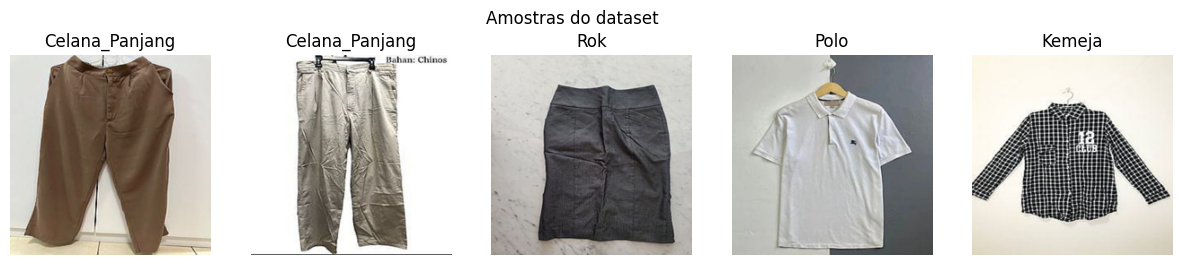

In [34]:
# Mostrar 5 imagens aleatórias no dataset
import random

sample_paths = random.sample(image_paths, 5)

plt.figure(figsize=(15, 3))
for i, path in enumerate(sample_paths):
    img = Image.open(path).resize((224, 224))
    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.title(os.path.basename(os.path.dirname(path)))
    plt.axis('off')
plt.suptitle("Amostras do dataset")
plt.show()

## Pre-processamento das imagens

* A MobileNetV2 espera imagens com formato (224, 224, 3) e pré-processadas.

* A função trata qualquer erro de imagem corrompida ou malformada.

In [11]:
# Função para carregar e pré-processar uma imagem para a MobileNetV2
def load_and_preprocess_image(img_path, target_size=(224, 224)):
    try:
        img = Image.open(img_path).convert('RGB')  # Garante que tem 3 canais (RGB)
        img = img.resize(target_size)              # Redimensiona para 224x224
        img_array = image.img_to_array(img)        # Converte para array numpy
        img_array = np.expand_dims(img_array, axis=0)  # Adiciona dimensão extra (batch size)
        img_array = preprocess_input(img_array)    # Pré-processa como a MobileNet espera
        return img_array
    except Exception as e:
        print(f"Erro ao processar imagem {img_path}: {e}")
        return None

## Carregar o modelo MobileNetV2 pré-treinado

* O modelo usará o peso do treinamento com o ImageNet
* O modelo retorna vetores de características (embeddings) para cada imagem.
* A opção ``pooling='avg'`` faz um "resumo" das ativações finais em um vetor fixo (1280 dimensões).

In [12]:
# Carrega o modelo MobileNetV2 sem a camada final de classificação
base_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')

# O modelo que usaremos para extrair embeddings
model = Model(inputs=base_model.input, outputs=base_model.output)

/tmp/ipython-input-331909080.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


## Extrair os embeddings para todas as imagens do dataset

Vamos aplicar o modelo a todas as imagens e guardar os vetores resultantes.

* Para cada imagem válida, extraímos o vetor de características com a MobileNetV2.

* Guardamos os vetores em embeddings e os caminhos válidos em valid_image_paths.

In [13]:
# Extrair embeddings (vetores) para todas as imagens do dataset
print("Extraindo embeddings para todas as imagens...")

embeddings = []
valid_image_paths = []

for path in image_paths:
    img_array = load_and_preprocess_image(path)
    if img_array is not None:
        feat = model.predict(img_array, verbose=0)
        embeddings.append(feat.flatten())
        valid_image_paths.append(path)

embeddings = np.array(embeddings)
print("Embeddings extraídos:", embeddings.shape)

Extraindo embeddings para todas as imagens...
Embeddings extraídos: (7500, 1280)


## Função para encontrar imagens semelhantes

* Essa função pega a imagem de entrada, extrai seu vetor, e calcula a similaridade de cosseno com todos os vetores do dataset.

* Retorna os top_n mais parecidos, com seus caminhos e scores.

In [14]:
# Função para encontrar imagens semelhantes usando similaridade por cosseno
def find_similar_images(input_image_path, model, embeddings, image_paths, top_n=5):
    img_array = load_and_preprocess_image(input_image_path)

    if img_array is None:
        print("Erro ao processar a imagem de entrada.")
        return []

    # Extrair vetor da imagem de entrada
    input_embedding = model.predict(img_array, verbose=0).flatten()

    # Calcular similaridade com todas as imagens do dataset
    similarities = cosine_similarity([input_embedding], embeddings)[0]

    # Obter os índices das top_n imagens mais similares (exceto a própria imagem se estiver no dataset)
    top_indices = similarities.argsort()[::-1][:top_n]

    similar_images = [(image_paths[i], similarities[i]) for i in top_indices]
    return similar_images

## Buscar e exibir imagens semelhantes

In [24]:
# Função para buscar os produtos mais semelhantes a uma imagem da internet
def find_similar_from_url(img_url, model, embeddings, image_paths, top_n=5):
    # Baixar a imagem
    response = requests.get(img_url)
    img = Image.open(BytesIO(response.content)).convert("RGB")
    img = img.resize((224, 224))

    # Pré-processar e extrair features
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    query_embedding = model.predict(img_array).flatten().reshape(1, -1)

    # Calcular similaridade
    similarities = cosine_similarity(query_embedding, embeddings)[0]
    top_indices = similarities.argsort()[-top_n:][::-1]

    # Exibir a imagem de entrada
    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.title("Imagem de entrada")
    plt.axis("off")
    plt.show()

    # Mostrar os resultados semelhantes
    print("Imagens mais semelhantes:")
    plt.figure(figsize=(15, 3))
    for i, idx in enumerate(top_indices):
        similar_img = Image.open(image_paths[idx])
        plt.subplot(1, 5, i+1)
        plt.imshow(similar_img)
        plt.title(f"Similaridade: {similarities[idx]:.4f}")
        plt.axis("off")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


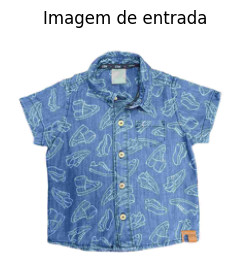

Imagens mais semelhantes:


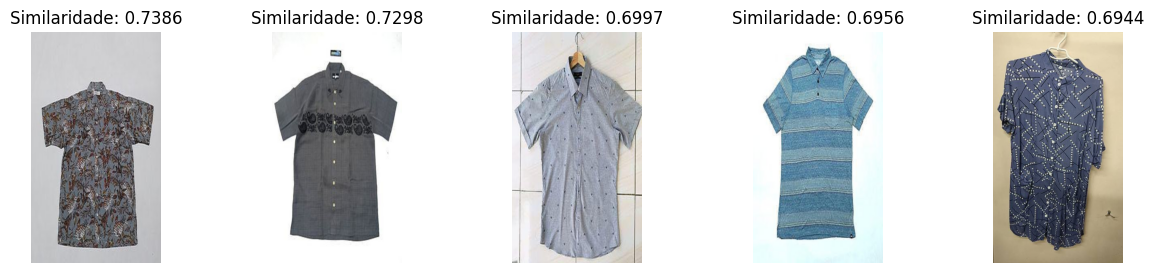

In [29]:
img_url = "https://images.tcdn.com.br/img/img_prod/577735/camisa_de_botoes_azul_manga_curta_infantil_18964355_1_c7f0c7a24c7a6db448aae1c389d9cabe_20240619115951.jpg"

find_similar_from_url(img_url, model, embeddings, valid_image_paths, top_n=5)